In [1]:
import os
import sys

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from project.model.coherence_from_data import auto_coherence, show_coherence, coherence
from project.model.detection import show_photons, Spad23, Spad512, merge_photons
from project.model.sample import Alexa647
from project.model.setup import Setup, ScanningSetup, WidefieldSetup

import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from abc import ABC, abstractmethod


np.random.seed(42)

# Set the global font to be DejaVu Sans, size 10 (or any other font you prefer)
plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# Font sizes for different elements
plt.rcParams['font.size'] = 12          # Base font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 12     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 10    # X tick label font size
plt.rcParams['ytick.labelsize'] = 10    # Y tick label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['figure.titlesize'] = 16   # Figure title font size

# Font weight
plt.rcParams['axes.labelweight'] = 'normal'  # Options: 'normal', 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Figure and axes settings
plt.rcParams['figure.figsize'] = (8, 6)     # Default figure size (width, height)
plt.rcParams['figure.dpi'] = 100            # Figure resolution
plt.rcParams['savefig.dpi'] = 300           # Saved figure resolution (high quality for thesis)
plt.rcParams['savefig.format'] = 'pdf'      # Default save format (PDF is vector format, good for thesis)
plt.rcParams['savefig.bbox'] = 'tight'      # Remove extra whitespace when saving

# Line and marker settings
plt.rcParams['lines.linewidth'] = 2.0       # Default line width
plt.rcParams['lines.markersize'] = 6        # Default marker size
plt.rcParams['lines.markeredgewidth'] = 1.0 # Marker edge width

# Axes settings
plt.rcParams['axes.linewidth'] = 1.2        # Axes border line width
plt.rcParams['axes.spines.top'] = False     # Remove top spine
plt.rcParams['axes.spines.right'] = False   # Remove right spine
plt.rcParams['axes.grid'] = False            # Enable grid by default
plt.rcParams['grid.alpha'] = 0.3            # Grid transparency
plt.rcParams['grid.linewidth'] = 0.8        # Grid line width

# Tick settings
plt.rcParams['xtick.major.size'] = 5        # X major tick size
plt.rcParams['xtick.minor.size'] = 3        # X minor tick size
plt.rcParams['ytick.major.size'] = 5        # Y major tick size
plt.rcParams['ytick.minor.size'] = 3        # Y minor tick size
plt.rcParams['xtick.major.width'] = 1.2     # X major tick width
plt.rcParams['xtick.minor.width'] = 0.8     # X minor tick width
plt.rcParams['ytick.major.width'] = 1.2     # Y major tick width
plt.rcParams['ytick.minor.width'] = 0.8     # Y minor tick width
plt.rcParams['xtick.direction'] = 'in'      # Tick direction: 'in', 'out', 'inout'
plt.rcParams['ytick.direction'] = 'in'

# Legend settings
plt.rcParams['legend.frameon'] = True       # Legend frame
plt.rcParams['legend.framealpha'] = 0.9     # Legend frame transparency
plt.rcParams['legend.fancybox'] = True      # Rounded corners for legend
plt.rcParams['legend.numpoints'] = 1        # Number of points in legend for line plots

# LaTeX settings (optional - for high-quality mathematical expressions)
plt.rcParams['text.usetex'] = False         # Set to True if you have LaTeX installed
plt.rcParams['mathtext.default'] = 'regular'  # Math font style

# Color settings - you can define a custom color palette
thesis_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=thesis_colors)

Theoretical Background

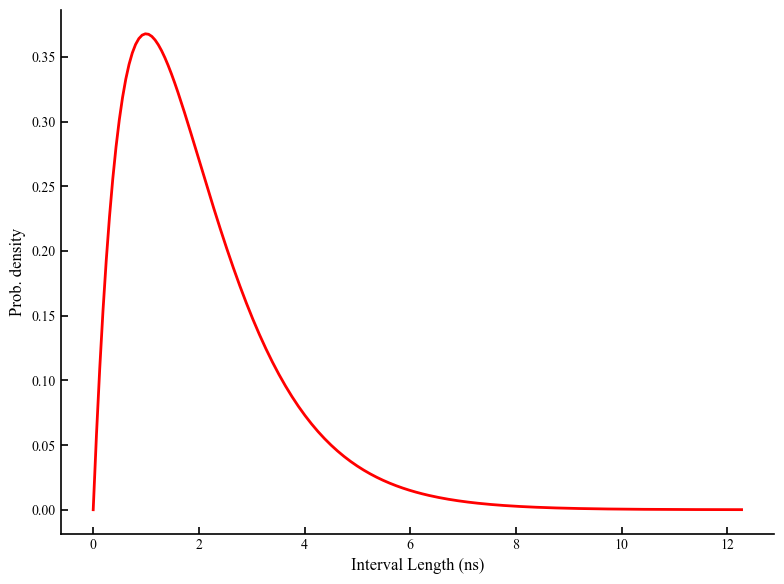

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Set random seed for reproducibility


# Parameters
k_ex = 1.0
k_em = 1.0
n_events = 5000

# Generate inter-arrival times (exponentially distributed)
intervals = np.random.exponential(1/k_ex, n_events) + np.random.exponential(1/k_em, n_events)

X = np.random.exponential(1/k_ex, n_events)
Y = np.random.exponential(1/k_em, n_events)
Z = X + Y
# Generate cumulative arrival times
arrival_times = np.cumsum(intervals)

# Plot histogram of intervals
plt.figure()
#plt.hist(intervals, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Overlay theoretical exponential distribution
x = np.linspace(0, max(intervals), 100)
theoretical1 = gamma.pdf(x, a=2, scale=k_ex + k_em)
theoretical2 = (k_ex+k_em)**2 *x * np.exp(-(k_ex+k_em) * x)

def hypoexp_pdf(z, a, b):
    if abs(a - b) < 1e-10:  # Equal rates case (Gamma)
        return a**2 * z * np.exp(-a * z)
    else:  # Different rates case
        return (a * b / (b - a)) * (np.exp(-a * z) - np.exp(-b * z))

# Plot theoretical curve
z_theory = np.linspace(0, max(Z), 200)
theoretical = [hypoexp_pdf(z, k_ex, k_em) for z in z_theory]
plt.plot(z_theory, theoretical, 'r-', linewidth=2, 
         label=f'Theoretical (a={k_ex}, b={k_em})')

#plt.plot(x, theoretical1, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, 5*theoretical1*theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')


plt.xlabel('Interval Length (ns)')
plt.ylabel('Prob. density')
#increase textsize of plot


plt.tight_layout()
plt.show()

Plot showing basic anti-bunching effect

Starting scanning experiment: 0.5×0.5 μm area...
Generated 1 emitters
Running scan...
Starting scan of 0.5×0.5 µm² area with 1×1 positions
Step size: 0.500 × 0.500 µm
ISM processing enabled with alpha=0.5
Progress: 100.0% (1/1), Est. remaining time: 0.0s
Scan completed in 0.41 seconds
Calculation summary: 1 successful calculations, 0 failed calculations, 0 skipped due to low photon count (<10)
Performing ISM processing...
ISM processing completed in 0.55 seconds


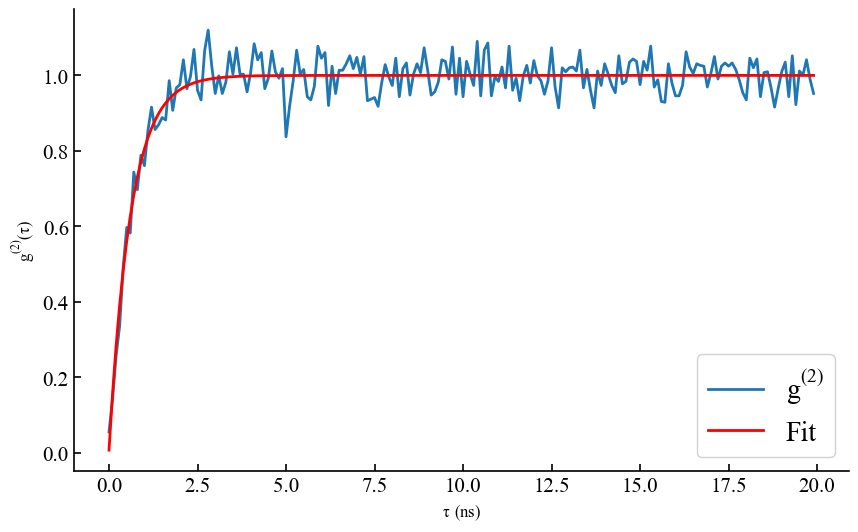

In [8]:
from project.simulations.run_scanning_experiment import run_scanning_experiment
from project.model.coherence_from_data import fit_coherence_function
setup, scan_data, _, _, _ = run_scanning_experiment(
    positions = (1,1),
    laser_power= 500E3,
    area_size = (0.5,0.5),
    emitter_density = 5, show_plots=False, save_data=False)

g2 = setup.scan_data['g2_data'][(0,0)][0]
bins = setup.scan_data['g2_data'][(0,0)][1]
fit,popt,pcov = fit_coherence_function(bins, g2, method='with_k', initial_guess = [3,2])

#Plot
plt.figure(figsize=(10, 6))
plt.plot(bins, g2, label=r"$g^{(2)}$")

#plot coherence curve
plt.plot(bins,fit, label='Fit', color='red')
plt.xlabel(r"$\tau \  (ns)$")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(fontsize=20)

In [ ]:
from project.simulations.run_scanning_experiment import run_scanning_experiment
from project.model.coherence_from_data import fit_coherence_function
# setup, scan_data, _, _, _ = run_scanning_experiment(
#     positions = (10,10),
#     laser_power= 100E3,
#     area_size = (1,1),
#     emitters_manual=[(0,0)], show_plots=True, save_data=False)


def gaussian_2d(coords, amplitude, x0, y0, sigma_x, sigma_y):
    """2D Gaussian function"""
    x, y = coords
    return amplitude * np.exp(-((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2)))
def get_psf_params(image):
    from scipy.optimize import curve_fit
    """
    Extract PSF amplitude and sigma from a centered PSF image.
    
    Args:
        image: 2D numpy array containing the PSF
    
    Returns:
        tuple: (amplitude, sigma) where sigma is the average of sigma_x and sigma_y
    """
    # Get image dimensions and center coordinates
    h, w = image.shape
    cx, cy = w // 2, h // 2
    
    # Create coordinate grids
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    
    # Initial guess: amplitude = max value, center at image center, sigma ~ image_size/6
    p0 = [np.max(image), cx, cy, min(w, h) / 6, min(w, h) / 6]
    
    # Fit 2D Gaussian
    try:
        popt, _ = curve_fit(gaussian_2d, (X, Y), image.ravel(), p0=p0)
        amplitude, _, _, sigma_x, sigma_y = popt
        sigma = (sigma_x + sigma_y) / 2  # Average sigma
        return amplitude, abs(sigma)
    except:
        # Fallback: use simple estimates
        amplitude = np.max(image)
        # Estimate sigma from full width at half maximum
        half_max = amplitude / 2
        mask = image > half_max
        sigma = np.sqrt(np.sum(mask)) / (2 * np.sqrt(2 * np.log(2)))
        return amplitude, sigma

def extract_psf(laser_power, pixel_size, plot=False):
    """
    Extract the PSF for both intensity and G2 difference maps for a given laser power.

    Args:
        laser_power (float): The laser power in mW.
        pixel_size (float): The pixel size in micrometers.
        plot (bool): Whether to plot the PSF and fitted Gaussian.
    Returns:
        (dict, dict): two dicts containing the PSF parameters (amplitude in counts, sigma in um).
    """

    #do a measurment with one emitter at the center
    setup, scan_data, _, _, metadata = run_scanning_experiment(
        positions = (20,20),
        laser_power= laser_power,
        area_size = (pixel_size*20,pixel_size*20),
        emitters_manual=[(0,0)], show_plots=False, save_data=False)
    
    I_amplitude, I_sigma = get_psf_params(setup.scan_data['photon_count_map'])
    G_amplitude, G_sigma = get_psf_params(setup.scan_data['G2_diff_map'])

    I_sigma = I_sigma * pixel_size  # Convert pixel sigma to micrometers
    G_sigma = G_sigma * pixel_size  # Convert pixel sigma to micrometers
    I_psf = {'amplitude': I_amplitude, 'sigma': I_sigma} #
    G2diff_psf = {'amplitude': G_amplitude, 'sigma': G_sigma} #

    if plot:
        # plot a line through middle of the PSF
        plt.figure(figsize=(10, 6))
        mid_y = setup.scan_data['photon_count_map'].shape[0] // 2
        plt.plot(setup.scan_data['photon_count_map'][mid_y, :], label='Horizontal line through PSF')
        # plot the fitted Gaussian
        x = np.arange(setup.scan_data['photon_count_map'].shape[1])
        fitted_gaussian = gaussian_2d((x, np.full_like(x, mid_y)), I_amplitude, x0=x.mean(), y0=mid_y, sigma_x=I_sigma/pixel_size, sigma_y=I_sigma/pixel_size)
        plt.plot(x, fitted_gaussian, label='Fitted Gaussian', color='red')
        plt.legend()

        # now for G2 diff
        plt.figure(figsize=(10, 6))
        plt.plot(setup.scan_data['G2_diff_map'][mid_y, :], label='Horizontal line through G2 diff PSF')
        # plot the fitted Gaussian
        fitted_gaussian_G2 = gaussian_2d((x, np.full_like(x, mid_y)), G_amplitude, x0=x.mean(), y0=mid_y, sigma_x=G_sigma/pixel_size, sigma_y=G_sigma/pixel_size)
        plt.plot(x, fitted_gaussian_G2, label='Fitted Gaussian G2 diff', color='red')
        plt.legend()

    return I_psf, G2diff_psf


#     return psf
# ipsf, gpsf = extract_psf(laser_power=300E3, pixel_size=0.05)
# print(ipsf, gpsf)

# g2 = setup.scan_data['g2_data'][(0,0)][0]
# bins = setup.scan_data['g2_data'][(0,0)][1]
# fit,popt,pcov = fit_coherence_function(bins, g2, method='with_k', initial_guess = [3,2])

# #Plot
# plt.figure(figsize=(10, 6))
# plt.plot(bins, g2, label=r"$g^{(2)}$")

# #plot coherence curve
# plt.plot(bins,fit, label='Fit', color='red')
# plt.xlabel(r"$\tau \  (ns)$")
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# plt.ylabel(r"$g^{(2)}(\tau)$")
# plt.legend(fontsize=20)

Starting scanning experiment: 1.0×1.0 μm area...
Manually created 1 emitter(s). All 1 emitters are within bounds (-0.5, 0.5, -0.5, 0.5)
Running scan...
Starting scan of 1.0×1.0 µm² area with 20×20 positions
Step size: 0.050 × 0.050 µm
ISM processing enabled with alpha=0.5
Progress: 2.5% (10/400), Est. remaining time: 79.7s
Progress: 5.0% (20/400), Est. remaining time: 87.7s
Progress: 7.5% (30/400), Est. remaining time: 82.7s
Progress: 10.0% (40/400), Est. remaining time: 92.3s
Progress: 12.5% (50/400), Est. remaining time: 90.2s
Progress: 15.0% (60/400), Est. remaining time: 92.3s
Progress: 17.5% (70/400), Est. remaining time: 93.9s
Progress: 20.0% (80/400), Est. remaining time: 96.0s
Progress: 22.5% (90/400), Est. remaining time: 94.8s
Progress: 25.0% (100/400), Est. remaining time: 94.5s
Progress: 27.5% (110/400), Est. remaining time: 92.8s
Progress: 30.0% (120/400), Est. remaining time: 91.9s
Progress: 32.5% (130/400), Est. remaining time: 90.3s
Progress: 35.0% (140/400), Est. remai

Results

In [ ]:
# # Parameter Sweep Results Analysis
# 
# This notebook reads and plots the results from parameter sweep experiments.

# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load parameter sweep results
data_files = glob.glob("./project/data/parameter_sweep_parallel_20250618_155701.json")
#data_files = glob.glob("./project/data/parameter_sweep_parallel_20250624_094717.json")
#data_files = glob.glob("./project/data/parameter_sweep_parallel_20250624_101413.json")
if not data_files:
    print("No parameter sweep files found!")
    print("Make sure to update the path to your actual data file")
else:
    # Use the most recent file
    latest_file = max(data_files)
    print(f"Loading data from: {latest_file}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)

Loading data from: ./project/data/parameter_sweep_parallel_20250624_101413.json


Loaded 2 data points
Laser powers: [200000.]
Emitter densities: [ 5 10]


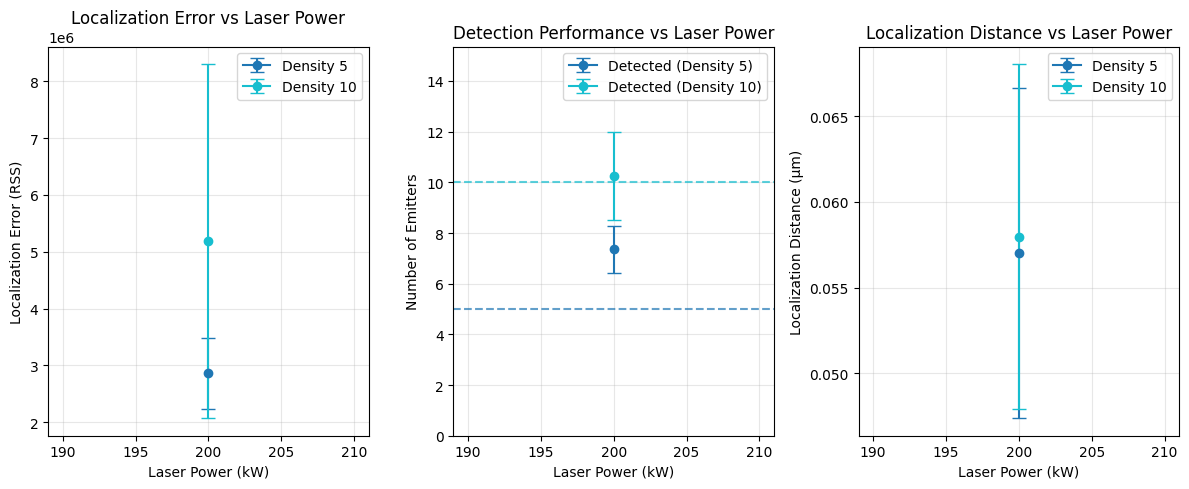

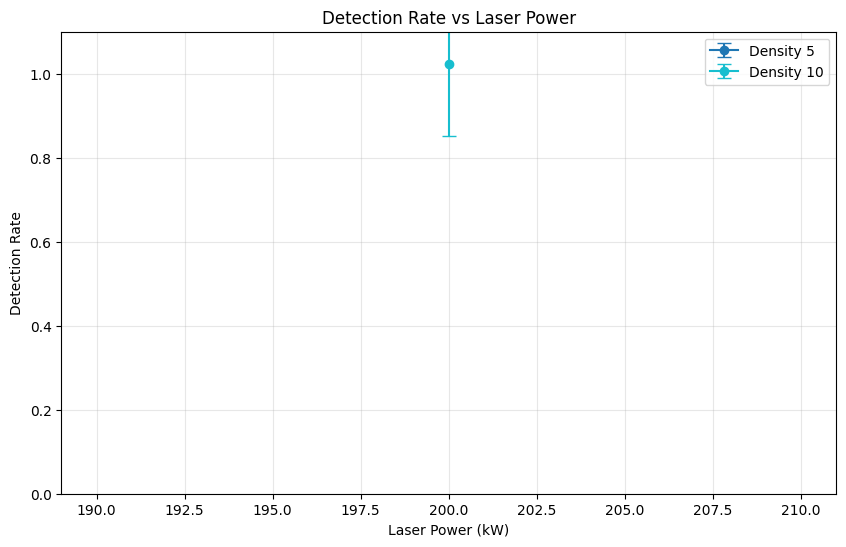


SUMMARY STATISTICS
Density  Power (kW)   Loc Error    Det Rate  
------------------------------------------------------------
5        200          2857630.573  1.472     
10       200          5186435.640  1.024     


In [5]:
# %%
# Extract data for plotting
laser_powers = []
emitter_densities = []
localization_errors = []
localization_errors_std = []
detection_rates = []
detection_rates_std = []
localization_distances = []
localization_distances_std = []



for key, result in sweep_data['results'].items():
    laser_powers.append(result['laser_power'])
    emitter_densities.append(result['emitter_density'])
    localization_errors.append(result['mean_localization_error'])
    localization_errors_std.append(result['std_localization_error'])
    detection_rates.append(result['mean_detection_rate'])
    detection_rates_std.append(result['std_detection_rate'])
    localization_distances.append(result['mean_distance'])
    localization_distances_std.append(result['std_distance'])

# Convert to numpy arrays
laser_powers = np.array(laser_powers)
emitter_densities = np.array(emitter_densities)
localization_errors = np.array(localization_errors)
localization_errors_std = np.array(localization_errors_std)
detection_rates = np.array(detection_rates)
detection_rates_std = np.array(detection_rates_std)
localization_distances = np.array(localization_distances)
localization_distances_std = np.array(localization_distances_std)

print(f"Loaded {len(laser_powers)} data points")
print(f"Laser powers: {np.unique(laser_powers)}")
print(f"Emitter densities: {np.unique(emitter_densities)}")

# %%
# Plot 1: Laser Power vs Localization Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
# Group by emitter density for different colors
unique_densities = np.unique(emitter_densities)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(laser_powers[mask]/1000, localization_errors[mask], 
                yerr=localization_errors_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel('Laser Power (kW)')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

# %%
# Plot 2: Laser Power vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    
    # Calculate number of emitters detected and ground truth
    # Assuming area_size = (0.5, 0.5) = 0.25 μm²
    area_size = 1  # This should match your simulation area
    n_ground_truth = density * area_size
    n_detected = detection_rates[mask] * n_ground_truth
    n_detected_std = detection_rates_std[mask] * n_ground_truth
    
    # Plot ground truth (constant line)
    plt.axhline(y=n_ground_truth, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(laser_powers[mask]/1000, n_detected, 
                yerr=n_detected_std,
                marker='o', linestyle='-', 
                color=colors[i], capsize=5,
                label=f'Detected (Density {density})')

plt.ylim(0, np.max(n_detected) * 1.5)  # Set y-limits to avoid crowding
plt.xlabel('Laser Power (kW)')
plt.ylabel('Number of Emitters')
plt.title('Detection Performance vs Laser Power')

plt.legend()
plt.grid(True, alpha=0.3)
# %%
# Plot 3: Laser Power vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(laser_powers[mask]/1000, localization_distances[mask], 
                yerr=localization_distances_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)
plt.xlabel('Laser Power (kW)')
plt.ylabel('Localization Distance (μm)')
plt.title('Localization Distance vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Alternative plot: Detection Rate vs Laser Power
plt.figure(figsize=(10, 6))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(laser_powers[mask]/1000, detection_rates[mask], 
                yerr=detection_rates_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel('Laser Power (kW)')
plt.ylabel('Detection Rate')
plt.title('Detection Rate vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)  # Detection rate should be between 0 and 1
plt.show()

# %%
# Summary statistics table
print("\nSUMMARY STATISTICS")
print("="*60)
print(f"{'Density':<8} {'Power (kW)':<12} {'Loc Error':<12} {'Det Rate':<10}")
print("-"*60)

for key, result in sweep_data['results'].items():
    density = result['emitter_density']
    power = result['laser_power']/1000
    loc_err = result['mean_localization_error']
    det_rate = result['mean_detection_rate']
    
    print(f"{density:<8} {power:<12.0f} {loc_err:<12.3f} {det_rate:<10.3f}")

## Noise results ##

***Dark Count Rate***

In [8]:
# # Parameter Sweep Results Analysis
# 
# This notebook reads and plots the results from parameter sweep experiments.

# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load parameter sweep results
data_files = glob.glob("./project/data/noise_sweep_2025-06-19_ec6daa.json")
if not data_files:
    print("No parameter sweep files found!")
    print("Make sure to update the path to your actual data file")
else:
    # Use the most recent file
    latest_file = max(data_files)
    print(f"Loading data from: {latest_file}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)

Loading data from: ./project/data/noise_sweep_2025-06-19_ec6daa.json


Loaded 6 data points
Laser powers: [200000.]
Emitter densities: [5]


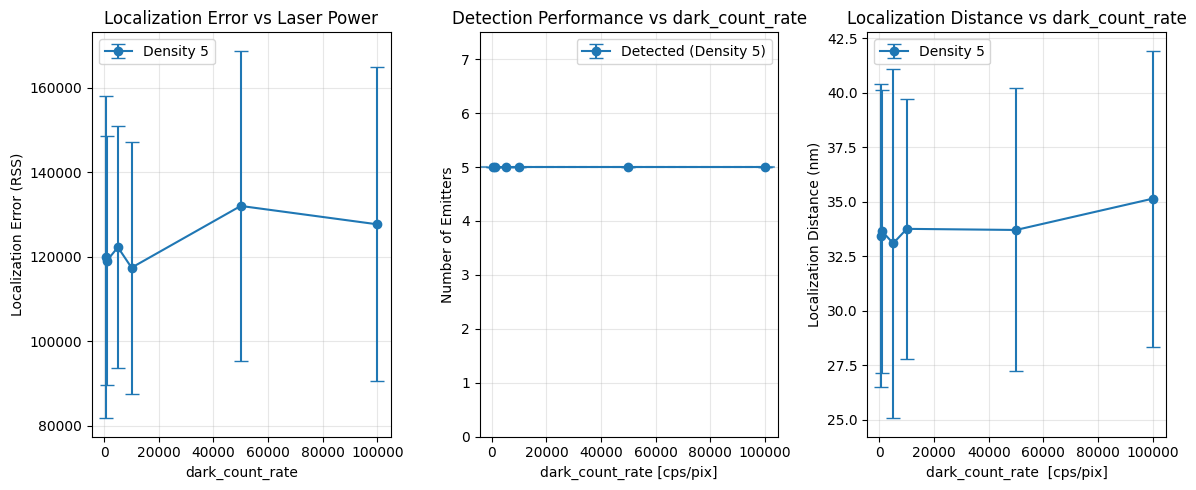

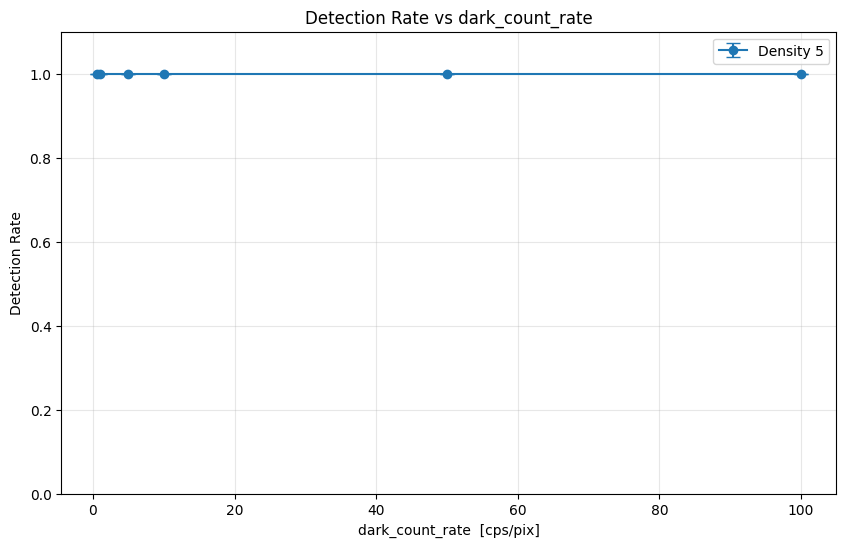

In [ ]:
# %%
# Extract data for plotting

noise_params = []
noise_levels = []
localization_errors = []
localization_errors_std = []
detection_rates = []
detection_rates_std = []
localization_distances = []
localization_distances_std = []
laser_powers = []
emitter_densities = []


for key, result in sweep_data['sweep_results'].items():
    laser_powers.append(result['laser_power'])
    emitter_densities.append(result['emitter_density'])
    localization_errors.append(result['summary_data']['mean_localization_error'])
    localization_errors_std.append(result['summary_data']['std_localization_error'])
    detection_rates.append(result['summary_data']['mean_detection_rate'])
    detection_rates_std.append(result['summary_data']['std_detection_rate'])
    localization_distances.append(result['summary_data']['mean_distance'])
    localization_distances_std.append(result['summary_data']['std_distance'])
    noise_levels.append(result['noise_level'])
    noise_params.append(result['noise_parameter'])

# Convert to numpy arrays
noise_levels = np.array(noise_levels)
noise_params = np.array(noise_params)
laser_powers = np.array(laser_powers)
emitter_densities = np.array(emitter_densities)
localization_errors = np.array(localization_errors)
localization_errors_std = np.array(localization_errors_std)
detection_rates = np.array(detection_rates)
detection_rates_std = np.array(detection_rates_std)
localization_distances = np.array(localization_distances)
localization_distances_std = np.array(localization_distances_std)

print(f"Loaded {len(laser_powers)} data points")
print(f"Laser powers: {np.unique(laser_powers)}")
print(f"Emitter densities: {np.unique(emitter_densities)}")

# %%
# Plot 1: Laser Power vs Localization Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
# Group by emitter density for different colors
unique_densities = np.unique(emitter_densities)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_errors[mask], 
                yerr=localization_errors_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel(f'{noise_params[0]}')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

# %%
# Plot 2: Laser Power vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    
    # Calculate number of emitters detected and ground truth
    # Assuming area_size = (0.5, 0.5) = 0.25 μm²
    area_size = 1  # This should match your simulation area
    n_ground_truth = density * area_size
    n_detected = detection_rates[mask] * n_ground_truth
    n_detected_std = detection_rates_std[mask] * n_ground_truth
    
    # Plot ground truth (constant line)
    plt.axhline(y=n_ground_truth, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(noise_levels[mask], n_detected, 
                yerr=n_detected_std,
                marker='o', linestyle='-', 
                color=colors[i], capsize=5,
                label=f'Detected (Density {density})')

plt.ylim(0, np.max(n_detected) * 1.5)  # Set y-limits to avoid crowding
plt.xlabel(f'{noise_params[0]} [cps/pix]')
plt.ylabel('Number of Emitters')
plt.title(f'Detection Performance vs {noise_params[0]}')

plt.legend()
plt.grid(True, alpha=0.3)
# %%
# Plot 3: Laser Power vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_distances[mask]*1000, 
                yerr=localization_distances_std[mask]*1000,
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)
plt.xlabel(f'{noise_params[0]}  [cps/pix]')
plt.ylabel('Localization Distance (nm)')
plt.title(f'Localization Distance vs {noise_params[0]}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


***Dead Time***

In [18]:
# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load parameter sweep results
data_files = glob.glob("./project/data/noise_sweep_2025-06-19_5a1ef4.json")
if not data_files:
    print("No parameter sweep files found!")
    print("Make sure to update the path to your actual data file")
else:
    # Use the most recent file
    latest_file = max(data_files)
    print(f"Loading data from: {latest_file}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)

Loading data from: ./project/data/noise_sweep_2025-06-19_5a1ef4.json


Loaded 5 data points
Laser powers: [200000.]
Emitter densities: [5]


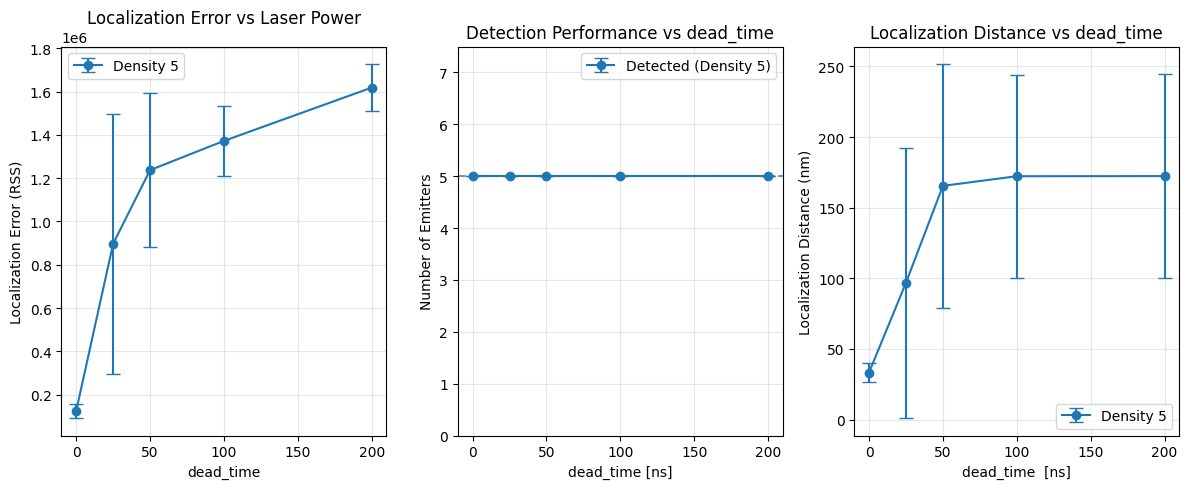

In [21]:
# %%
# Extract data for plotting

noise_params = []
noise_levels = []
localization_errors = []
localization_errors_std = []
detection_rates = []
detection_rates_std = []
localization_distances = []
localization_distances_std = []
laser_powers = []
emitter_densities = []


for key, result in sweep_data['sweep_results'].items():
    laser_powers.append(result['laser_power'])
    emitter_densities.append(result['emitter_density'])
    localization_errors.append(result['summary_data']['mean_localization_error'])
    localization_errors_std.append(result['summary_data']['std_localization_error'])
    detection_rates.append(result['summary_data']['mean_detection_rate'])
    detection_rates_std.append(result['summary_data']['std_detection_rate'])
    localization_distances.append(result['summary_data']['mean_distance'])
    localization_distances_std.append(result['summary_data']['std_distance'])
    noise_levels.append(result['noise_level'])
    noise_params.append(result['noise_parameter'])

# Convert to numpy arrays
noise_levels = np.array(noise_levels)
noise_params = np.array(noise_params)
laser_powers = np.array(laser_powers)
emitter_densities = np.array(emitter_densities)
localization_errors = np.array(localization_errors)
localization_errors_std = np.array(localization_errors_std)
detection_rates = np.array(detection_rates)
detection_rates_std = np.array(detection_rates_std)
localization_distances = np.array(localization_distances)
localization_distances_std = np.array(localization_distances_std)

print(f"Loaded {len(laser_powers)} data points")
print(f"Laser powers: {np.unique(laser_powers)}")
print(f"Emitter densities: {np.unique(emitter_densities)}")

# %%
# Plot 1: Laser Power vs Localization Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
# Group by emitter density for different colors
unique_densities = np.unique(emitter_densities)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_errors[mask], 
                yerr=localization_errors_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel(f'{noise_params[0]}')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

# %%
# Plot 2: Laser Power vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    
    # Calculate number of emitters detected and ground truth
    # Assuming area_size = (0.5, 0.5) = 0.25 μm²
    area_size = 1  # This should match your simulation area
    n_ground_truth = density * area_size
    n_detected = detection_rates[mask] * n_ground_truth
    n_detected_std = detection_rates_std[mask] * n_ground_truth
    
    # Plot ground truth (constant line)
    plt.axhline(y=n_ground_truth, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(noise_levels[mask], n_detected, 
                yerr=n_detected_std,
                marker='o', linestyle='-', 
                color=colors[i], capsize=5,
                label=f'Detected (Density {density})')

plt.ylim(0, np.max(n_detected) * 1.5)  # Set y-limits to avoid crowding
plt.xlabel(f'{noise_params[0]} [ns]')
plt.ylabel('Number of Emitters')
plt.title(f'Detection Performance vs {noise_params[0]}')

plt.legend()
plt.grid(True, alpha=0.3)
# %%
# Plot 3: Laser Power vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_distances[mask]*1000, 
                yerr=localization_distances_std[mask]*1000,
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)
plt.xlabel(f'{noise_params[0]}  [ns]')
plt.ylabel('Localization Distance (nm)')
plt.title(f'Localization Distance vs {noise_params[0]}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***Afterpulsing***

In [22]:
# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load parameter sweep results
data_files = glob.glob("./project/data/noise_sweep_2025-06-19_703f75.json")
if not data_files:
    print("No parameter sweep files found!")
    print("Make sure to update the path to your actual data file")
else:
    # Use the most recent file
    latest_file = max(data_files)
    print(f"Loading data from: {latest_file}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)

Loading data from: ./project/data/noise_sweep_2025-06-19_703f75.json


Loaded 5 data points
Laser powers: [200000.]
Emitter densities: [5]


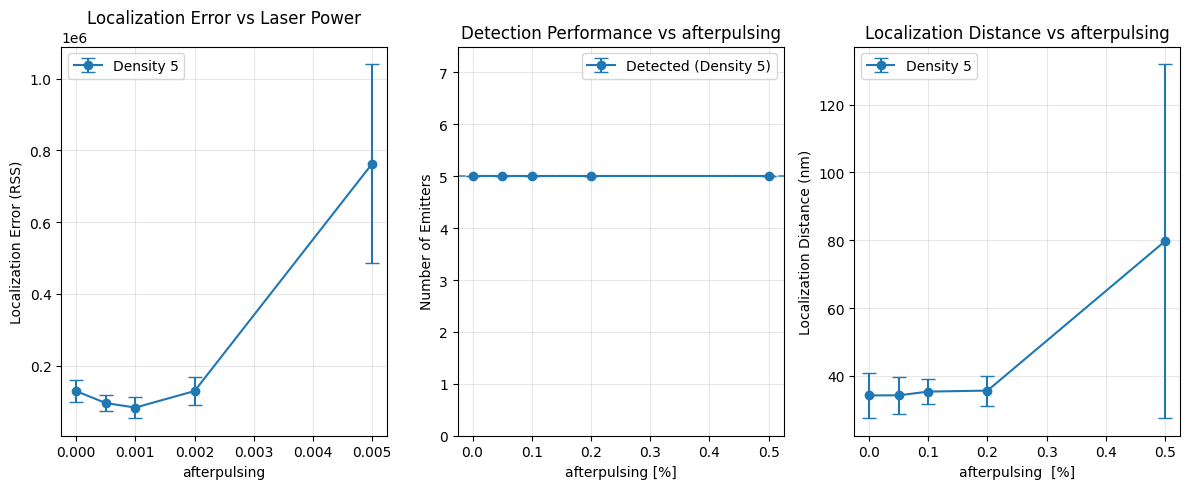

In [24]:
# %%
# Extract data for plotting

noise_params = []
noise_levels = []
localization_errors = []
localization_errors_std = []
detection_rates = []
detection_rates_std = []
localization_distances = []
localization_distances_std = []
laser_powers = []
emitter_densities = []


for key, result in sweep_data['sweep_results'].items():
    laser_powers.append(result['laser_power'])
    emitter_densities.append(result['emitter_density'])
    localization_errors.append(result['summary_data']['mean_localization_error'])
    localization_errors_std.append(result['summary_data']['std_localization_error'])
    detection_rates.append(result['summary_data']['mean_detection_rate'])
    detection_rates_std.append(result['summary_data']['std_detection_rate'])
    localization_distances.append(result['summary_data']['mean_distance'])
    localization_distances_std.append(result['summary_data']['std_distance'])
    noise_levels.append(result['noise_level'])
    noise_params.append(result['noise_parameter'])

# Convert to numpy arrays
noise_levels = np.array(noise_levels)
noise_params = np.array(noise_params)
laser_powers = np.array(laser_powers)
emitter_densities = np.array(emitter_densities)
localization_errors = np.array(localization_errors)
localization_errors_std = np.array(localization_errors_std)
detection_rates = np.array(detection_rates)
detection_rates_std = np.array(detection_rates_std)
localization_distances = np.array(localization_distances)
localization_distances_std = np.array(localization_distances_std)

print(f"Loaded {len(laser_powers)} data points")
print(f"Laser powers: {np.unique(laser_powers)}")
print(f"Emitter densities: {np.unique(emitter_densities)}")

# %%
# Plot 1: Laser Power vs Localization Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
# Group by emitter density for different colors
unique_densities = np.unique(emitter_densities)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_errors[mask], 
                yerr=localization_errors_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel(f'{noise_params[0]}')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

# %%
# Plot 2: Laser Power vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    
    # Calculate number of emitters detected and ground truth
    # Assuming area_size = (0.5, 0.5) = 0.25 μm²
    area_size = 1  # This should match your simulation area
    n_ground_truth = density * area_size
    n_detected = detection_rates[mask] * n_ground_truth
    n_detected_std = detection_rates_std[mask] * n_ground_truth
    
    # Plot ground truth (constant line)
    plt.axhline(y=n_ground_truth, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(noise_levels[mask]*100, n_detected, 
                yerr=n_detected_std,
                marker='o', linestyle='-', 
                color=colors[i], capsize=5,
                label=f'Detected (Density {density})')

plt.ylim(0, np.max(n_detected) * 1.5)  # Set y-limits to avoid crowding
plt.xlabel(f'{noise_params[0]} [%]')
plt.ylabel('Number of Emitters')
plt.title(f'Detection Performance vs {noise_params[0]}')

plt.legend()
plt.grid(True, alpha=0.3)
# %%
# Plot 3: Laser Power vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask]*100, localization_distances[mask]*1000, 
                yerr=localization_distances_std[mask]*1000,
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)
plt.xlabel(f'{noise_params[0]}  [%]')
plt.ylabel('Localization Distance (nm)')
plt.title(f'Localization Distance vs {noise_params[0]}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***Crosstalk***

In [25]:
# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load parameter sweep results
data_files = glob.glob("./project/data/noise_sweep_2025-06-19_cb2370.json")
if not data_files:
    print("No parameter sweep files found!")
    print("Make sure to update the path to your actual data file")
else:
    # Use the most recent file
    latest_file = max(data_files)
    print(f"Loading data from: {latest_file}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)

Loading data from: ./project/data/noise_sweep_2025-06-19_cb2370.json


Loaded 5 data points
Laser powers: [200000.]
Emitter densities: [5]


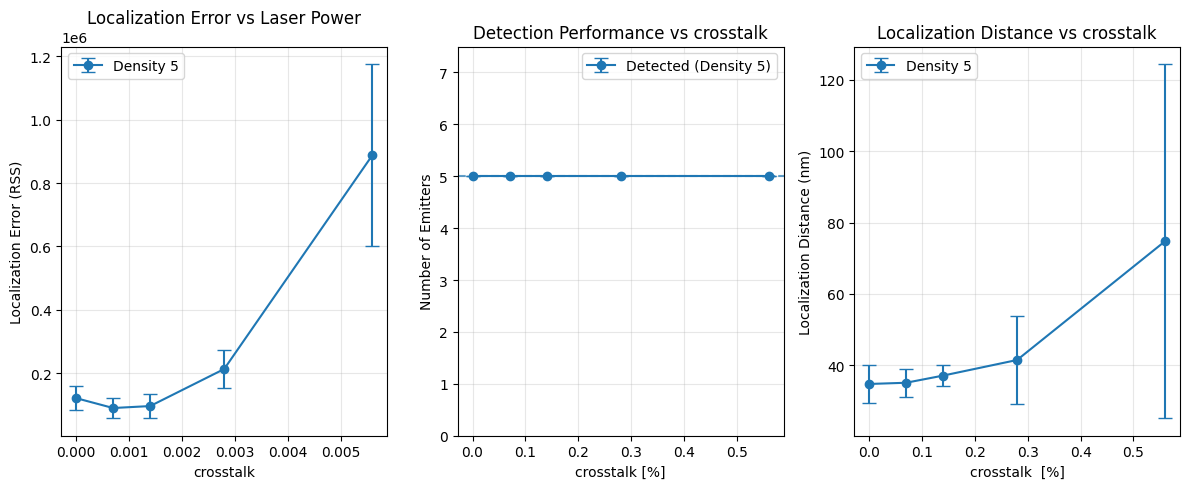

In [26]:
# %%
# Extract data for plotting

noise_params = []
noise_levels = []
localization_errors = []
localization_errors_std = []
detection_rates = []
detection_rates_std = []
localization_distances = []
localization_distances_std = []
laser_powers = []
emitter_densities = []


for key, result in sweep_data['sweep_results'].items():
    laser_powers.append(result['laser_power'])
    emitter_densities.append(result['emitter_density'])
    localization_errors.append(result['summary_data']['mean_localization_error'])
    localization_errors_std.append(result['summary_data']['std_localization_error'])
    detection_rates.append(result['summary_data']['mean_detection_rate'])
    detection_rates_std.append(result['summary_data']['std_detection_rate'])
    localization_distances.append(result['summary_data']['mean_distance'])
    localization_distances_std.append(result['summary_data']['std_distance'])
    noise_levels.append(result['noise_level'])
    noise_params.append(result['noise_parameter'])

# Convert to numpy arrays
noise_levels = np.array(noise_levels)
noise_params = np.array(noise_params)
laser_powers = np.array(laser_powers)
emitter_densities = np.array(emitter_densities)
localization_errors = np.array(localization_errors)
localization_errors_std = np.array(localization_errors_std)
detection_rates = np.array(detection_rates)
detection_rates_std = np.array(detection_rates_std)
localization_distances = np.array(localization_distances)
localization_distances_std = np.array(localization_distances_std)

print(f"Loaded {len(laser_powers)} data points")
print(f"Laser powers: {np.unique(laser_powers)}")
print(f"Emitter densities: {np.unique(emitter_densities)}")

# %%
# Plot 1: Laser Power vs Localization Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
# Group by emitter density for different colors
unique_densities = np.unique(emitter_densities)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask], localization_errors[mask], 
                yerr=localization_errors_std[mask],
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)

plt.xlabel(f'{noise_params[0]}')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Laser Power')
plt.legend()
plt.grid(True, alpha=0.3)

# %%
# Plot 2: Laser Power vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    
    # Calculate number of emitters detected and ground truth
    # Assuming area_size = (0.5, 0.5) = 0.25 μm²
    area_size = 1  # This should match your simulation area
    n_ground_truth = density * area_size
    n_detected = detection_rates[mask] * n_ground_truth
    n_detected_std = detection_rates_std[mask] * n_ground_truth
    
    # Plot ground truth (constant line)
    plt.axhline(y=n_ground_truth, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(noise_levels[mask]*100, n_detected, 
                yerr=n_detected_std,
                marker='o', linestyle='-', 
                color=colors[i], capsize=5,
                label=f'Detected (Density {density})')

plt.ylim(0, np.max(n_detected) * 1.5)  # Set y-limits to avoid crowding
plt.xlabel(f'{noise_params[0]} [%]')
plt.ylabel('Number of Emitters')
plt.title(f'Detection Performance vs {noise_params[0]}')

plt.legend()
plt.grid(True, alpha=0.3)
# %%
# Plot 3: Laser Power vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    mask = emitter_densities == density
    plt.errorbar(noise_levels[mask]*100, localization_distances[mask]*1000, 
                yerr=localization_distances_std[mask]*1000,
                marker='o', linestyle='-', label=f'Density {density}',
                color=colors[i], capsize=5)
plt.xlabel(f'{noise_params[0]}  [%]')
plt.ylabel('Localization Distance (nm)')
plt.title(f'Localization Distance vs {noise_params[0]}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Combined Noise Results ##

In [ ]:
# Parameter Sweep Results Comparison Analysis
# 
# This notebook reads and compares results from two parameter sweep experiments
# with different measurement dwell times.

# %%
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# %%
# Load both parameter sweep results
data_files = [
    #"./project/data/parameter_sweep_parallel_20250624_094717.json",
    #"./project/data/parameter_sweep_parallel_20250624_101413.json"
    #"./project/data/parameter_sweep_parallel_20250627_073415.json",
    #"./project/data/parameter_sweep_parallel_20250627_221606.json"
    #"./project/data/parameter_sweep_parallel_20250702_175826.json"
    #"./project/data/parameter_sweep_parallel_20250702_190319.json"
]

# Assume the dwell times for each file (you may need to adjust these)
dwell_times = [0.1, 0.5]  # in ms

sweep_data_list = []
for i, file_path in enumerate(data_files):
    if os.path.exists(file_path):
        print(f"Loading data from: {file_path}")
        with open(file_path, 'r') as f:
            data = json.load(f)
            data['dwell_time'] = dwell_times[i]  # Add dwell time metadata
            sweep_data_list.append(data)
    else:
        print(f"File not found: {file_path}")

if not sweep_data_list:
    print("No parameter sweep files found!")
    print("Make sure to update the paths to your actual data files")

# %%
# Extract data for plotting from both files
all_data = []

for sweep_data in sweep_data_list:
    dwell_time = sweep_data['dwell_time']
    
    laser_powers = []
    emitter_densities = []
    localization_errors = []
    localization_errors_std = []
    detection_rates = []
    detection_rates_std = []
    localization_distances = []
    localization_distances_std = []
    
    for key, result in sweep_data['results'].items():
        laser_powers.append(result['laser_power'])
        emitter_densities.append(result['emitter_density'])
        localization_errors.append(result['mean_localization_error'])
        localization_errors_std.append(result['std_localization_error'])
        detection_rates.append(result['mean_detection_rate'])
        detection_rates_std.append(result['std_detection_rate'])
        localization_distances.append(result['mean_distance'])
        localization_distances_std.append(result['std_distance'])
    
    # Convert to numpy arrays
    data_dict = {
        'dwell_time': dwell_time,
        'laser_powers': np.array(laser_powers),
        'emitter_densities': np.array(emitter_densities),
        'localization_errors': np.array(localization_errors),
        'localization_errors_std': np.array(localization_errors_std),
        'detection_rates': np.array(detection_rates),
        'detection_rates_std': np.array(detection_rates_std),
        'localization_distances': np.array(localization_distances),
        'localization_distances_std': np.array(localization_distances_std)
    }
    
    all_data.append(data_dict)
    
    print(f"Dwell time {dwell_time} ms: {len(laser_powers)} data points")
    print(f"  Laser powers: {np.unique(laser_powers)}")
    print(f"  Emitter densities: {np.unique(emitter_densities)}")

# %%
# Create comparison plots
plt.figure(figsize=(15, 5))

# Get unique emitter densities (assuming same across both datasets)
unique_densities = np.unique(all_data[0]['emitter_densities'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_densities)))

# Plot 1: Dwell Time vs Localization Error
plt.subplot(1, 3, 1)

for i, density in enumerate(unique_densities):
    dwell_times_plot = []
    errors_plot = []
    errors_std_plot = []
    
    for data in all_data:
        mask = data['emitter_densities'] == density
        if np.any(mask):
            # Average across all laser powers for this density and dwell time
            mean_error = np.mean(data['localization_errors'][mask])
            std_error = np.sqrt(np.mean(data['localization_errors_std'][mask]**2))
            
            dwell_times_plot.append(data['dwell_time'])
            errors_plot.append(mean_error)
            errors_std_plot.append(std_error)
    
    plt.errorbar(dwell_times_plot, errors_plot, 
                yerr=errors_std_plot,
                marker='o', linestyle='', label=f'Density {density}',
                color=colors[i], capsize=5, markersize=8)

plt.xlabel('Measurement Dwell Time (ms)')
plt.ylabel('Localization Error (RSS)')
plt.title('Localization Error vs Dwell Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(dwell_times)

# Plot 2: Dwell Time vs Detection Performance
plt.subplot(1, 3, 2)

for i, density in enumerate(unique_densities):
    dwell_times_plot = []
    detected_plot = []
    detected_std_plot = []
    
    for data in all_data:
        mask = data['emitter_densities'] == density
        if np.any(mask):
            # Calculate number of emitters detected and ground truth
            area_size = 1  # This should match your simulation area
            n_ground_truth = density * area_size
            
            mean_detection_rate = np.mean(data['detection_rates'][mask])
            std_detection_rate = np.sqrt(np.mean(data['detection_rates_std'][mask]**2))
            
            n_detected = mean_detection_rate * n_ground_truth
            n_detected_std = std_detection_rate * n_ground_truth
            
            dwell_times_plot.append(data['dwell_time'])
            detected_plot.append(n_detected)
            detected_std_plot.append(n_detected_std)
    
    # Plot ground truth (constant line)
    plt.axhline(y=density * 1, color=colors[i], linestyle='--', alpha=0.7)
    
    # Plot detected emitters
    plt.errorbar(dwell_times_plot, detected_plot, 
                yerr=detected_std_plot,
                marker='o', linestyle='', 
                color=colors[i], capsize=5, markersize=8,
                label=f'Detected (Density {density})')

plt.xlabel('Measurement Dwell Time (ms)')
plt.ylabel('Number of Emitters')
plt.title('Detection Performance vs Dwell Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(dwell_times)

# Plot 3: Dwell Time vs Localization Distance
plt.subplot(1, 3, 3)

for i, density in enumerate(unique_densities):
    dwell_times_plot = []
    distances_plot = []
    distances_std_plot = []
    
    for data in all_data:
        mask = data['emitter_densities'] == density
        if np.any(mask):
            # Average across all laser powers for this density and dwell time
            mean_distance = np.mean(data['localization_distances'][mask])
            std_distance = np.sqrt(np.mean(data['localization_distances_std'][mask]**2))
            
            dwell_times_plot.append(data['dwell_time'])
            distances_plot.append(mean_distance)
            distances_std_plot.append(std_distance)

    print(dwell_times_plot)
    
    plt.errorbar(dwell_times_plot, [d*1000 for d in distances_plot], 
                yerr=[d*1000 for d in distances_std_plot],
                marker='o', linestyle='', label=f'Density {density}',
                color=colors[i], capsize=5, markersize=8)

plt.xlabel('Measurement Dwell Time (ms)')
plt.ylabel('Localization Distance (nm)')
plt.title('Localization Distance vs Dwell Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(dwell_times)

plt.tight_layout()
plt.show()

File not found: ./project/data/parameter_sweep_parallel_20250702_175826.json./project/data/parameter_sweep_parallel_20250702_190319.json
No parameter sweep files found!
Make sure to update the paths to your actual data files


IndexError: list index out of range

<Figure size 1500x500 with 0 Axes>